In [23]:
import os
import numpy as np
import cupy as cp
import numba as nb
from numba import cuda
import scipy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from sklearn.mixture import GaussianMixture

In [24]:
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML" # "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [25]:
def fit_gmm_components(intensity_image, n_components=3, n_bins=256):
    """
    Fit Gaussian Mixture Model to SAR intensity image.
    
    The 3 components typically represent:
    - C1: Shadow (low intensity)
    - C2: Clutter (medium intensity)  
    - T: Target scattering points (high intensity)
    
    Args:
        intensity_image: Log-mapped intensity image in range [0, 1]
        n_components: Number of Gaussian components (default 3)
        n_bins: Number of bins for histogram visualization (default 256)
        random_state: Random seed for reproducibility
    
    Returns:
        Dictionary with GMM parameters and fitted model
    """
    # Flatten the intensity image for GMM fitting
    intensity_flat = intensity_image.flatten().reshape(-1, 1)
    
    # Fit GMM with 3 components
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',  # Full covariance matrices
        max_iter=10_000,
        # random_state=random_state,
        n_init=50  # Multiple initializations for stability
    )
    gmm.fit(intensity_flat)
    
    # Get parameters
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_
    
    # Sort by mean (ascending): C1 (shadow) < C2 (clutter) < T (target)
    sorted_idx = np.argsort(means)
    
    theta_C1 = {
        'mu': means[sorted_idx[0]], 
        'sigma': stds[sorted_idx[0]], 
        'pi': weights[sorted_idx[0]],
        'label': 'C1'
    }
    theta_C2 = {
        'mu': means[sorted_idx[1]], 
        'sigma': stds[sorted_idx[1]], 
        'pi': weights[sorted_idx[1]],
        'label': 'C2'
    }
    theta_T = {
        'mu': means[sorted_idx[2]], 
        'sigma': stds[sorted_idx[2]], 
        'pi': weights[sorted_idx[2]],
        'label': 'Target'
    }
    
    # Compute histogram for visualization
    histogram, bin_edges = np.histogram(intensity_flat, bins=n_bins, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return {
        'gmm': gmm,
        'components': [theta_C1, theta_C2, theta_T],
        'histogram': (histogram, bin_centers),
        'sorted_idx': sorted_idx
    }


def visualize_gmm_fit(intensity_image, gmm_result):
    """
    Visualize the GMM fit on intensity histogram (Figure 6c style).
    
    Matches the SSR paper's visualization with:
    - Y-axis: Number of Pixels (not density)
    - Gaussian curves scaled to match histogram counts
    """
    components = gmm_result['components']
    gmm = gmm_result['gmm']
    
    # Create histogram with COUNTS (not density)
    intensity_flat = intensity_image.flatten()
    counts, bin_edges = np.histogram(intensity_flat, bins=256, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_centers[1] - bin_centers[0]
    
    plt.figure(figsize=(12, 6))
    
    # Plot histogram as bar chart
    plt.bar(bin_centers, counts, width=bin_width, 
            alpha=0.5, label='Intensity Histogram', color='gray')
    
    # Plot individual Gaussian components
    x = np.linspace(0, 1, 500)
    colors = ['blue', 'red', 'green']  # C1=blue, C2=red, T=green (from paper)
    labels = ['Shadow (C1)', 'Clutter (C2)', 'Target (T)']
    
    total_pixels = len(intensity_flat)
    
    for comp, color, label in zip(components, colors, labels):
        # Gaussian PDF (without weight)
        gaussian_pdf = (1/(comp['sigma']*np.sqrt(2*np.pi))) * \
                       np.exp(-0.5*((x - comp['mu'])/comp['sigma'])**2)
        
        # Scale to pixel counts: weight × total_pixels × bin_width × PDF
        gaussian_counts = comp['pi'] * total_pixels * bin_width * gaussian_pdf
        
        plt.plot(x, gaussian_counts, color=color, linewidth=2.5,
                label=f"{label}: μ={comp['mu']:.3f}, σ={comp['sigma']:.3f}")
    
    # Plot total GMM (sum of all components)
    total_pdf = np.exp(gmm.score_samples(x.reshape(-1, 1)))
    total_counts = total_pixels * bin_width * total_pdf
    plt.plot(x, total_counts, 'k--', linewidth=2, label='GMM Total')
    
    plt.xlabel('Intensity')
    plt.ylabel('Number of Pixels')
    plt.title('GMM Fit: SAR Intensity Components')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [26]:
def extract_clutter_hard_segmentation(log_mapped_image, gmm_result):
    """
    Perform hard 3-class segmentation using GMM labels ordered by mean intensity.
    
    Class order (Figure 6b style):
    - 0: Shadow (low intensity)
    - 1: Clutter (medium intensity)
    - 2: Target (high intensity)
    
    Args:
        log_mapped_image: Log-mapped intensity image [0, 1]
        gmm_result: Dictionary from fit_gmm_components()
    
    Returns:
        result: dict with segmentation map, masks, and per-class pixels
    """
    gmm = gmm_result['gmm']
    sorted_idx = gmm_result['sorted_idx']
    
    intensities = log_mapped_image.flatten().reshape(-1, 1)
    raw_labels = gmm.predict(intensities)
    
    ordered_labels = np.zeros_like(raw_labels)
    ordered_labels[raw_labels == sorted_idx[0]] = 0  # Shadow
    ordered_labels[raw_labels == sorted_idx[1]] = 1  # Clutter
    ordered_labels[raw_labels == sorted_idx[2]] = 2  # Target
    
    segmented_map = ordered_labels.reshape(log_mapped_image.shape)
    shadow_mask = (segmented_map == 0)
    clutter_mask = (segmented_map == 1)
    target_mask = (segmented_map == 2)
    
    shadow_pixels = log_mapped_image[shadow_mask]
    clutter_pixels = log_mapped_image[clutter_mask]
    target_pixels = log_mapped_image[target_mask]
    
    return {
        'segmented_map': segmented_map,
        'shadow_mask': shadow_mask,
        'clutter_mask': clutter_mask,
        'target_mask': target_mask,
        'shadow_pixels': shadow_pixels,
        'clutter_pixels': clutter_pixels,
        'target_pixels': target_pixels
    }

def visualize_segmentation(log_mapped_image, gmm_result):
    """Visualize hard segmentation in Figure 6b-style colors."""
    
    seg = extract_clutter_hard_segmentation(log_mapped_image, gmm_result)
    segmented_map = seg['segmented_map']
    shadow_mask = seg['shadow_mask']
    clutter_mask = seg['clutter_mask']
    target_mask = seg['target_mask']
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 9))
    
    axes[0].imshow(log_mapped_image, cmap='gray')
    axes[0].set_title('Original Log-Mapped Image')
    axes[0].axis('off')
    
    class_cmap = ListedColormap(['#1f77b4', '#d62728', '#90EE90'])  # Shadow, Clutter, Target
    class_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], class_cmap.N)
    axes[1].imshow(segmented_map, cmap=class_cmap, norm=class_norm)
    axes[1].set_title('Figure 6b-style Segmentation')
    axes[1].axis('off')
    
    legend_handles = [
        Patch(facecolor='#1f77b4', edgecolor='black', label='Shadow (Blue)'),
        Patch(facecolor='#d62728', edgecolor='black', label='Clutter (Red)'),
        Patch(facecolor='#90EE90', edgecolor='black', label='Target (Light Green)')
    ]
    axes[1].legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=1, fontsize=9)
    
    overlay = np.stack([log_mapped_image, log_mapped_image, log_mapped_image], axis=-1)
    alpha = 0.3
    overlay[shadow_mask] = (1 - alpha) * overlay[shadow_mask] + alpha * np.array([31/255, 119/255, 180/255])
    overlay[clutter_mask] = (1 - alpha) * overlay[clutter_mask] + alpha * np.array([214/255, 39/255, 40/255])
    overlay[target_mask] = (1 - alpha) * overlay[target_mask] + alpha * np.array([144/255, 238/255, 144/255])
    
    axes[2].imshow(overlay)
    axes[2].set_title('Color Overlay on Original')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    total = log_mapped_image.size
    print(f"Total pixels: {total}")
    print(f"Shadow pixels: {shadow_mask.sum()} ({100*shadow_mask.sum()/total:.1f}%)")
    print(f"Clutter pixels: {clutter_mask.sum()} ({100*clutter_mask.sum()/total:.1f}%)")
    print(f"Target pixels: {target_mask.sum()} ({100*target_mask.sum()/total:.1f}%)")
    print()
    if shadow_mask.any():
        print(f"Shadow mean/std: {seg['shadow_pixels'].mean():.4f} / {seg['shadow_pixels'].std():.4f}")
    if clutter_mask.any():
        print(f"Clutter mean/std: {seg['clutter_pixels'].mean():.4f} / {seg['clutter_pixels'].std():.4f}")
    if target_mask.any():
        print(f"Target mean/std: {seg['target_pixels'].mean():.4f} / {seg['target_pixels'].std():.4f}")

In [27]:
ds = sorted(
        os.listdir(
            os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1")
    ))[0]

In [28]:
image = np.load(os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1", ds))

In [29]:
gmm_result = fit_gmm_components(image, n_components=3, n_bins=256)

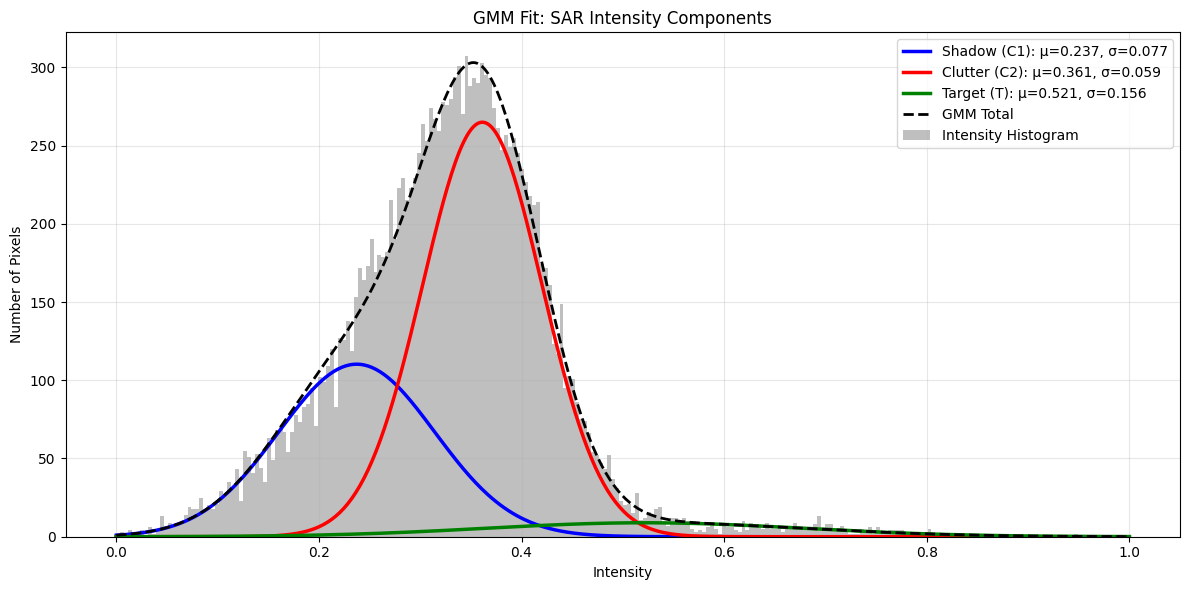

In [84]:
visualize_gmm_fit(image, gmm_result)

In [85]:
extract_clutter_hard_segmentation(image, gmm_result)

{'segmented_map': array([[0, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(128, 128)),
 'shadow_mask': array([[ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(128, 128)),
 'clutter_mask': array([[False,  True,  True, ..., False, False, False],
        [False,  True,  True, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False,

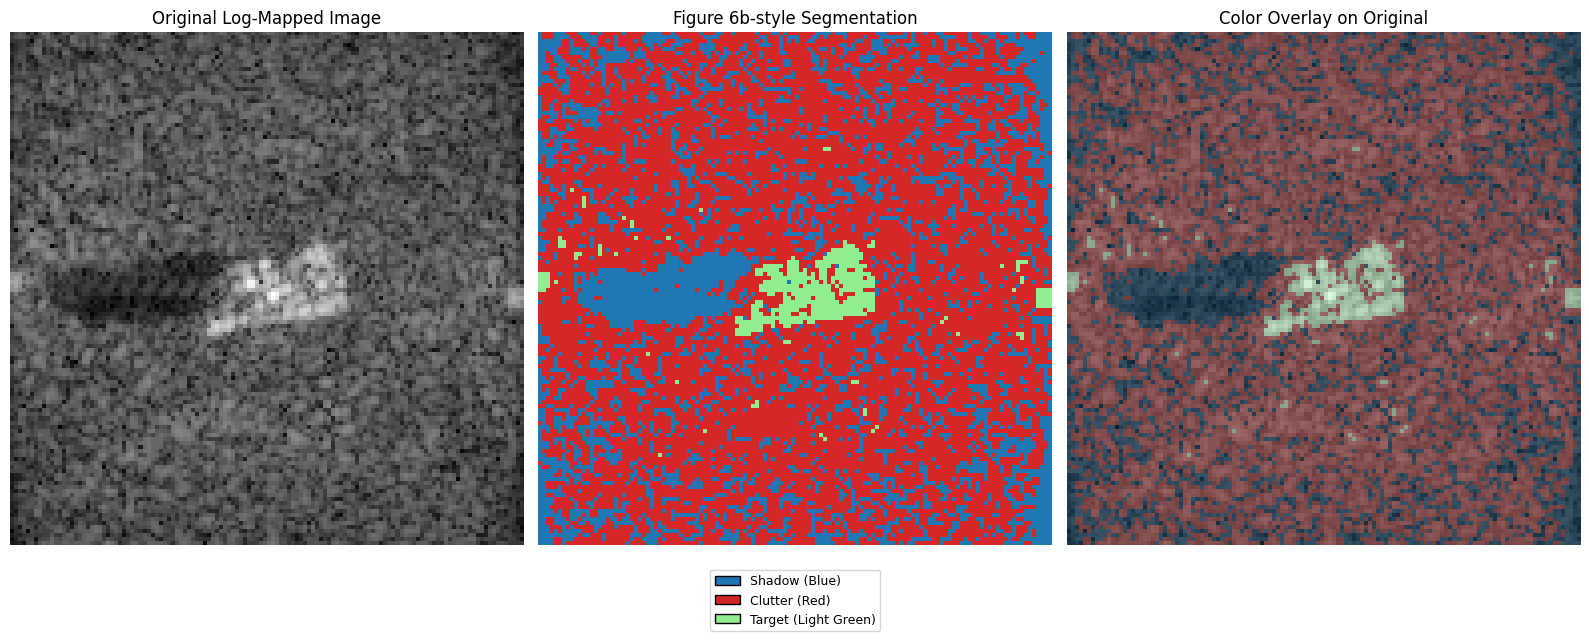

Total pixels: 16384
Shadow pixels: 4636 (28.3%)
Clutter pixels: 11256 (68.7%)
Target pixels: 492 (3.0%)

Shadow mean/std: 0.2086 / 0.0557
Clutter mean/std: 0.3648 / 0.0530
Target mean/std: 0.6364 / 0.0965


In [86]:
visualize_segmentation(image, gmm_result)

In [13]:
means_lst = []
stds_lst = []
data_folders = [os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth", folder) for folder in os.listdir(os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth"))]
for folder in data_folders:
    print(folder)
    image_paths_in_f = os.listdir(folder)
    for image_path in image_paths_in_f:
        print(f"Processing {image_path}...")
        image = np.load(os.path.join(folder, image_path))
        image_flat = image.flatten().reshape(-1, 1)
        gmm = GaussianMixture(
            n_components=3,
            covariance_type='full',  # Full covariance matrices
            max_iter=1_000,
            # random_state=random_state,
            # n_init=50  # Multiple initializations for stability
            warm_start=True  # Use previous fit as initialization for faster convergence
        )
        gmm.fit(image_flat)
        means = gmm.means_.flatten()
        sorted_idx = np.argsort(means)
        raw_labels = gmm.predict(image_flat)
        ordered_labels  = np.zeros_like(raw_labels)
        for i in range(len(sorted_idx)):
            ordered_labels[raw_labels == sorted_idx[i]] = i
        segmented_map = ordered_labels.reshape(image.shape)
        non_target_mask = image[segmented_map != 2]
        means_lst.append(non_target_mask.mean())
        stds_lst.append(non_target_mask.std())
        print(f"Mean: {non_target_mask.mean():.4f}, Std: {non_target_mask.std():.4f}")

/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/synth/2s1
Processing 2s1_synth_A_elevDeg_015_azCenter_010_22_serial_b01.npy...
Mean: 0.3177, Std: 0.0872
Processing 2s1_synth_A_elevDeg_015_azCenter_011_22_serial_b01.npy...
Mean: 0.3446, Std: 0.0930
Processing 2s1_synth_A_elevDeg_015_azCenter_012_22_serial_b01.npy...
Mean: 0.3291, Std: 0.0873
Processing 2s1_synth_A_elevDeg_015_azCenter_013_22_serial_b01.npy...
Mean: 0.3260, Std: 0.0910
Processing 2s1_synth_A_elevDeg_015_azCenter_014_22_serial_b01.npy...
Mean: 0.3569, Std: 0.0923
Processing 2s1_synth_A_elevDeg_015_azCenter_015_22_serial_b01.npy...
Mean: 0.3517, Std: 0.0926
Processing 2s1_synth_A_elevDeg_015_azCenter_016_22_serial_b01.npy...
Mean: 0.3465, Std: 0.0918
Processing 2s1_synth_A_elevDeg_015_azCenter_017_22_serial_b01.npy...
Mean: 0.3284, Std: 0.0915
Processing 2s1_synth_A_elevDeg_015_azCenter_018_22_serial_b01.npy...
Mean: 0.2773, Std: 0.0853
Processing 2s1_synth_A_elevDeg_015_azCenter_019_22_se

In [14]:
meas_means_lst = []
meas_stds_lst = []
data_folders = [os.path.join(data_workspace, "alvin_edited_files/log_mapping/real", folder) for folder in os.listdir(os.path.join(data_workspace, "alvin_edited_files/log_mapping/real"))]
for folder in data_folders:
    print(folder)
    image_paths_in_f = os.listdir(folder)
    for image_path in image_paths_in_f:
        print(f"Processing {image_path}...")
        image = np.load(os.path.join(folder, image_path))
        image_flat = image.flatten().reshape(-1, 1)
        gmm = GaussianMixture(
            n_components=3,
            covariance_type='full',  # Full covariance matrices
            max_iter=1_000,
            # random_state=random_state,
            # n_init=50  # Multiple initializations for stability
            warm_start=True  # Use previous fit as initialization for faster convergence
        )
        gmm.fit(image_flat)
        means = gmm.means_.flatten()
        sorted_idx = np.argsort(means)
        raw_labels = gmm.predict(image_flat)
        ordered_labels  = np.zeros_like(raw_labels)
        for i in range(len(sorted_idx)):
            ordered_labels[raw_labels == sorted_idx[i]] = i
        segmented_map = ordered_labels.reshape(image.shape)
        non_target_mask = image[segmented_map != 2]
        meas_means_lst.append(non_target_mask.mean())
        meas_stds_lst.append(non_target_mask.std())
        print(f"Mean: {non_target_mask.mean():.4f}, Std: {non_target_mask.std():.4f}")

/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/SAMPLE/alvin_edited_files/log_mapping/real/2s1
Processing 2s1_real_A_elevDeg_015_azCenter_010_22_serial_b01.npy...
Mean: 0.4112, Std: 0.0885
Processing 2s1_real_A_elevDeg_015_azCenter_011_22_serial_b01.npy...
Mean: 0.4528, Std: 0.0863
Processing 2s1_real_A_elevDeg_015_azCenter_012_22_serial_b01.npy...
Mean: 0.3924, Std: 0.0868
Processing 2s1_real_A_elevDeg_015_azCenter_013_22_serial_b01.npy...
Mean: 0.4096, Std: 0.0868
Processing 2s1_real_A_elevDeg_015_azCenter_014_22_serial_b01.npy...
Mean: 0.4430, Std: 0.0908
Processing 2s1_real_A_elevDeg_015_azCenter_015_22_serial_b01.npy...
Mean: 0.4553, Std: 0.0887
Processing 2s1_real_A_elevDeg_015_azCenter_016_22_serial_b01.npy...
Mean: 0.4604, Std: 0.0912
Processing 2s1_real_A_elevDeg_015_azCenter_017_22_serial_b01.npy...
Mean: 0.4245, Std: 0.0812
Processing 2s1_real_A_elevDeg_015_azCenter_018_22_serial_b01.npy...
Mean: 0.4615, Std: 0.0867
Processing 2s1_real_A_elevDeg_015_azCenter_019_22_serial_b01.np

In [15]:
log_synth_vals = list(zip(means_lst, stds_lst))
log_meas_vals = list(zip(meas_means_lst, meas_stds_lst))

In [16]:
log_synth_vals

[(np.float32(0.31773734), np.float32(0.08715622)),
 (np.float32(0.34458774), np.float32(0.093005255)),
 (np.float32(0.32914355), np.float32(0.087316185)),
 (np.float32(0.32597688), np.float32(0.0910033)),
 (np.float32(0.35685483), np.float32(0.09230205)),
 (np.float32(0.3516717), np.float32(0.09255023)),
 (np.float32(0.3464544), np.float32(0.09176805)),
 (np.float32(0.3284065), np.float32(0.09147238)),
 (np.float32(0.27727124), np.float32(0.08528278)),
 (np.float32(0.25941813), np.float32(0.08133705)),
 (np.float32(0.21981473), np.float32(0.07540133)),
 (np.float32(0.2844272), np.float32(0.08656387)),
 (np.float32(0.31647947), np.float32(0.090657786)),
 (np.float32(0.333783), np.float32(0.09385613)),
 (np.float32(0.33910307), np.float32(0.09385083)),
 (np.float32(0.33139807), np.float32(0.09327979)),
 (np.float32(0.26279554), np.float32(0.08338046)),
 (np.float32(0.27340356), np.float32(0.08492164)),
 (np.float32(0.28862348), np.float32(0.08735186)),
 (np.float32(0.29298753), np.float3

In [17]:
log_meas_vals

[(np.float32(0.41121468), np.float32(0.08846366)),
 (np.float32(0.45281795), np.float32(0.086300366)),
 (np.float32(0.39241153), np.float32(0.08680006)),
 (np.float32(0.40962), np.float32(0.086844616)),
 (np.float32(0.44296858), np.float32(0.090778515)),
 (np.float32(0.45534104), np.float32(0.088670574)),
 (np.float32(0.46042332), np.float32(0.09118202)),
 (np.float32(0.4244881), np.float32(0.0812362)),
 (np.float32(0.46150678), np.float32(0.0867219)),
 (np.float32(0.4416623), np.float32(0.08787808)),
 (np.float32(0.45645833), np.float32(0.090427004)),
 (np.float32(0.43895784), np.float32(0.084912375)),
 (np.float32(0.4581556), np.float32(0.08870768)),
 (np.float32(0.4031317), np.float32(0.08768459)),
 (np.float32(0.43952912), np.float32(0.088515006)),
 (np.float32(0.4442192), np.float32(0.08514148)),
 (np.float32(0.45854542), np.float32(0.09024723)),
 (np.float32(0.40375647), np.float32(0.0856873)),
 (np.float32(0.37589723), np.float32(0.086716115)),
 (np.float32(0.44904673), np.float

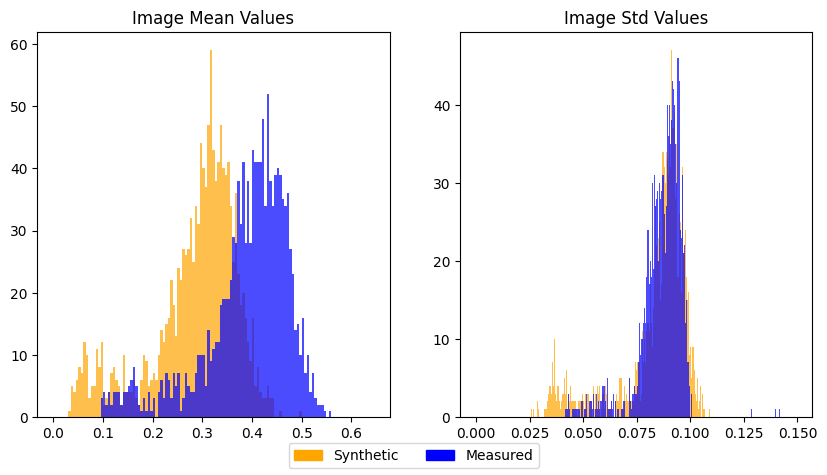

In [18]:
fig = plt.figure(figsize=(10, 5))

color_lst = ["orange", "blue"]
label_lst = ['Synthetic', 'Measured']

ax1 = fig.add_subplot(1, 2, 1)
ax1.hist([val[0] for val in log_synth_vals], bins = np.arange(0, 0.65, 0.005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax1.hist([val[0] for val in log_meas_vals], bins = np.arange(0, 0.65, 0.005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax1.set_title("Image Mean Values")

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist([val[1] for val in log_synth_vals], bins = np.arange(0, 0.15, 0.0005), alpha=0.7, label=label_lst[0], color=color_lst[0])
ax2.hist([val[1] for val in log_meas_vals], bins = np.arange(0, 0.15, 0.0005), alpha=0.7, label=label_lst[1], color=color_lst[1])
ax2.set_title("Image Std Values")

legend_handles = [
    Patch(color = color, label = ds) for ds, color in zip(label_lst, color_lst)
    ]
fig.legend(handles=legend_handles, loc = "lower center", ncol = 2)
plt.show()

In [58]:
def fit_gmm_histogram_based(intensity_image, n_components=3, n_bins=128, max_iter=10_0000, tol=1e-6, sigma_min=1e-6, random_state=42):
    """
    Fit a 1D GMM using histogram-weighted EM (paper-style).
    
    EM is performed on histogram bin centers b_m with weights = counts(m).
    This returns component parameters (mu, sigma, pi) sorted by ascending mean.
    """
    flat = intensity_image.reshape(-1)
    counts_all, bin_edges = np.histogram(flat, bins=n_bins, density=False)
    centers_all = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    non_zero = counts_all > 0
    centers = centers_all[non_zero].astype(np.float64)
    counts = counts_all[non_zero].astype(np.float64)
    total_pixels = float(counts.sum())
    M = centers.shape[0]

    if M < n_components:
        raise ValueError(f"Not enough non-empty bins ({M}) for n_components={n_components}.")

    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=n_components, n_init=10, random_state=random_state)
    km.fit(centers.reshape(-1, 1), sample_weight=counts)

    mu = km.cluster_centers_.flatten().astype(np.float64)
    sigma = np.full(n_components, max(np.std(flat), 1e-2), dtype=np.float64)
    pi = np.full(n_components, 1.0 / n_components, dtype=np.float64)

    prev_nll = np.inf

    for _ in range(max_iter):
        pdf = np.zeros((n_components, M), dtype=np.float64)
        for k in range(n_components):
            sk = max(sigma[k], sigma_min)
            z = (centers - mu[k]) / sk
            pdf[k, :] = (1.0 / (np.sqrt(2.0 * np.pi) * sk)) * np.exp(-0.5 * z * z)

        weighted_pdf = pi[:, None] * pdf
        denom = weighted_pdf.sum(axis=0)
        denom = np.maximum(denom, 1e-300)

        gamma = weighted_pdf / denom

        nk = (gamma * counts[None, :]).sum(axis=1)
        nk = np.maximum(nk, 1e-12)

        mu = ((gamma * counts[None, :]) @ centers) / nk

        var = np.zeros(n_components, dtype=np.float64)
        for k in range(n_components):
            diff = centers - mu[k]
            var[k] = np.sum(gamma[k, :] * counts * (diff ** 2)) / nk[k]
        sigma = np.sqrt(np.maximum(var, sigma_min ** 2))

        pi = nk / total_pixels
        pi = np.maximum(pi, 1e-12)
        pi = pi / pi.sum()

        nll = -np.sum(counts * np.log(denom))
        if np.abs(prev_nll - nll) <= tol * (1.0 + np.abs(prev_nll)):
            break
        prev_nll = nll

    sorted_idx = np.argsort(mu)
    mu_sorted = mu[sorted_idx]
    sigma_sorted = sigma[sorted_idx]
    pi_sorted = pi[sorted_idx]

    theta_C1 = {'mu': mu_sorted[0], 'sigma': sigma_sorted[0], 'pi': pi_sorted[0], 'label': 'C1'}
    theta_C2 = {'mu': mu_sorted[1], 'sigma': sigma_sorted[1], 'pi': pi_sorted[1], 'label': 'C2'}
    theta_T = {'mu': mu_sorted[2], 'sigma': sigma_sorted[2], 'pi': pi_sorted[2], 'label': 'Target'}

    return {
        'components': [theta_C1, theta_C2, theta_T],
        'mu': mu_sorted,
        'sigma': sigma_sorted,
        'pi': pi_sorted,
        'histogram': (counts_all, centers_all),
        'histogram_nonzero': (counts, centers)
    }

def predict_hist_gmm_labels(intensity_image, hist_gmm_result):
    """Predict hard labels (0=shadow, 1=clutter, 2=target) using histogram-EM parameters."""
    params = hist_gmm_result
    mu = np.asarray(params['mu'])
    sigma = np.asarray(params['sigma'])
    pi = np.asarray(params['pi'])

    x = intensity_image.reshape(-1).astype(np.float64)
    K = mu.shape[0]
    scores = np.zeros((K, x.shape[0]), dtype=np.float64)

    for k in range(K):
        sk = max(sigma[k], 1e-12)
        z = (x - mu[k]) / sk
        scores[k, :] = np.log(max(pi[k], 1e-300)) - np.log(np.sqrt(2.0 * np.pi) * sk) - 0.5 * z * z

    labels = np.argmax(scores, axis=0).reshape(intensity_image.shape)
    return labels

def compare_hist_em_vs_current_method(intensity_image, gmm_result, n_bins=256):
    """Fit histogram-EM and compare hard segmentation with current sklearn-predict method."""
    hist_result = fit_gmm_histogram_based(intensity_image, n_components=3, n_bins=n_bins)
    labels_hist = predict_hist_gmm_labels(intensity_image, hist_result)
    labels_current = extract_clutter_hard_segmentation(intensity_image, gmm_result)['segmented_map']

    agreement = (labels_hist == labels_current).mean()
    mismatch = int((labels_hist != labels_current).sum())

    print(f"Histogram-EM bins: {n_bins}")
    print(f"Agreement vs current method: {agreement*100:.4f}%")
    print(f"Mismatched pixels: {mismatch}/{intensity_image.size}")

    return {
        'hist_result': hist_result,
        'labels_hist': labels_hist,
        'labels_current': labels_current,
        'agreement': float(agreement),
        'mismatch_count': mismatch
    }

# Example usage:
comparison_hist = compare_hist_em_vs_current_method(image, gmm_result, n_bins=24)
comparison_hist['agreement']

Histogram-EM bins: 24
Agreement vs current method: 97.6013%
Mismatched pixels: 393/16384


0.97601318359375

Histogram-EM bins: 24
Agreement vs current method: 97.6013%
Mismatched pixels: 393/16384


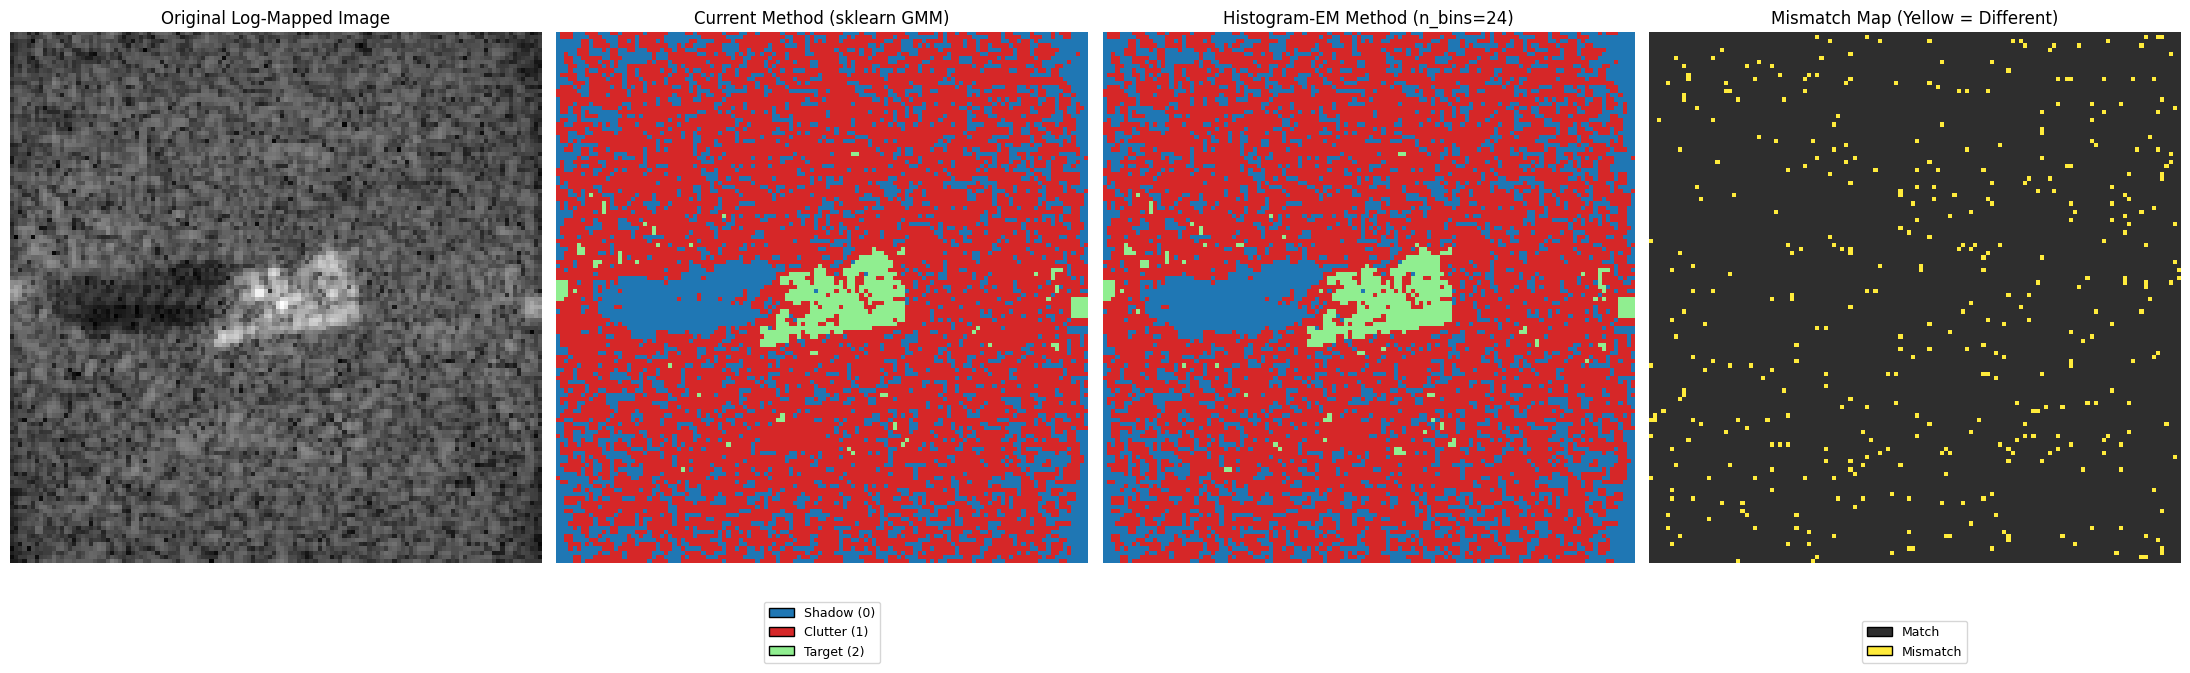

Agreement: 97.6013%
Mismatched pixels: 393/16384


In [68]:
def visualize_hist_em_vs_current(intensity_image, gmm_result, n_bins=256):
    """Visualize current sklearn-GMM segmentation vs histogram-EM segmentation."""
    comp = compare_hist_em_vs_current_method(intensity_image, gmm_result, n_bins=n_bins)
    labels_hist = comp['labels_hist']
    labels_current = comp['labels_current']
    mismatch = labels_hist != labels_current
    
    class_cmap = ListedColormap(['#1f77b4', '#d62728', '#90EE90'])
    class_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], class_cmap.N)
    mismatch_cmap = ListedColormap(['#2e2e2e', '#ffeb3b'])  # match / mismatch
    mismatch_norm = BoundaryNorm([-0.5, 0.5, 1.5], mismatch_cmap.N)
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    
    axes[0].imshow(intensity_image, cmap='gray')
    axes[0].set_title('Original Log-Mapped Image')
    axes[0].axis('off')
    
    axes[1].imshow(labels_current, cmap=class_cmap, norm=class_norm, interpolation='nearest')
    axes[1].set_title('Current Method (sklearn GMM)')
    axes[1].axis('off')
    
    axes[2].imshow(labels_hist, cmap=class_cmap, norm=class_norm, interpolation='nearest')
    axes[2].set_title(f'Histogram-EM Method (n_bins={n_bins})')
    axes[2].axis('off')
    
    axes[3].imshow(mismatch.astype(int), cmap=mismatch_cmap, norm=mismatch_norm, interpolation='nearest')
    axes[3].set_title('Mismatch Map (Yellow = Different)')
    axes[3].axis('off')
    
    class_handles = [
        Patch(facecolor='#1f77b4', edgecolor='black', label='Shadow (0)'),
        Patch(facecolor='#d62728', edgecolor='black', label='Clutter (1)'),
        Patch(facecolor='#90EE90', edgecolor='black', label='Target (2)')
    ]
    mismatch_handles = [
        Patch(facecolor='#2e2e2e', edgecolor='black', label='Match'),
        Patch(facecolor='#ffeb3b', edgecolor='black', label='Mismatch')
    ]
    axes[1].legend(handles=class_handles, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=9)
    axes[3].legend(handles=mismatch_handles, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Agreement: {comp['agreement']*100:.4f}%")
    print(f"Mismatched pixels: {comp['mismatch_count']}/{intensity_image.size}")
    
    return comp

# Visualize comparison
comparison_viz = visualize_hist_em_vs_current(image, gmm_result, n_bins=24)

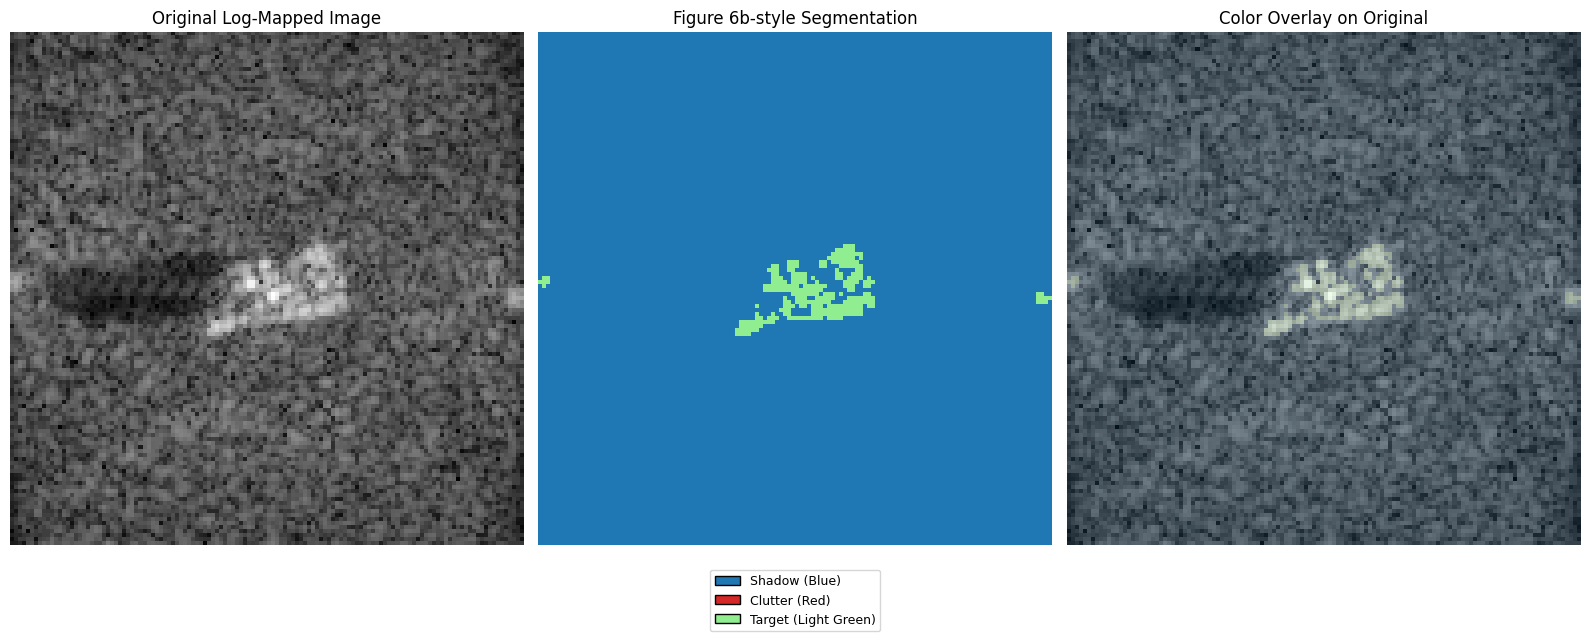

In [93]:
ds = sorted(
        os.listdir(
            os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1")
    ))[0]
image = np.load(os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1", ds))
image_flat = image.flatten().reshape(-1, 1)
gmm.fit(image_flat)
means = gmm.means_.flatten()
sorted_idx = np.argsort(means)

proba_raw = gmm.predict_proba(image_flat)
proba_sorted = proba_raw[:, sorted_idx]
biggest_proba_idx = np.argmax(proba_sorted, axis=1)
new_labels = np.zeros_like(biggest_proba_idx)
for i in range(len(new_labels)):
    if (biggest_proba_idx[i] == 2) and (proba_sorted[i, 2] >= 0.95):
        new_labels[i] = 2

segmented_map = new_labels.reshape(image.shape)
shadow_mask = (segmented_map == 0)
clutter_mask = (segmented_map == 1)
target_mask = (segmented_map == 2)

shadow_pixels = image[shadow_mask]
clutter_pixels = image[clutter_mask]
target_pixels = image[target_mask]

fig, axes = plt.subplots(1, 3, figsize=(16, 9))
    
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Log-Mapped Image')
axes[0].axis('off')

class_cmap = ListedColormap(['#1f77b4', '#d62728', '#90EE90'])  # Shadow, Clutter, Target
class_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], class_cmap.N)
axes[1].imshow(segmented_map, cmap=class_cmap, norm=class_norm)
axes[1].set_title('Figure 6b-style Segmentation')
axes[1].axis('off')

legend_handles = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='Shadow (Blue)'),
    Patch(facecolor='#d62728', edgecolor='black', label='Clutter (Red)'),
    Patch(facecolor='#90EE90', edgecolor='black', label='Target (Light Green)')
]
axes[1].legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=1, fontsize=9)

overlay = np.stack([image, image, image], axis=-1)
alpha = 0.15
overlay[shadow_mask] = (1 - alpha) * overlay[shadow_mask] + alpha * np.array([31/255, 119/255, 180/255])
overlay[clutter_mask] = (1 - alpha) * overlay[clutter_mask] + alpha * np.array([214/255, 39/255, 40/255])
overlay[target_mask] = (1 - alpha) * overlay[target_mask] + alpha * np.array([144/255, 238/255, 144/255])

axes[2].imshow(overlay)
axes[2].set_title('Color Overlay on Original')
axes[2].axis('off')

plt.tight_layout()
plt.show()